In [10]:
import numpy as np
# observation = np.load("../../data/after_prep_800-1000/beads_segments_7p5W.npy")
observation = np.load("../../data/after_prep_800-1000_artificial_noisy/artificial_noisy_7p5W.npy")
# observation = observation.transpose(0, 2, 1)

samples = np.load("../../results/test_0330/samples.npy")
avg = np.load("../../results/test_0330/avg.npy")

avg = avg.squeeze(1)
# avg = avg.transpose(0, 2, 1)

gt = np.load("../../data/after_prep_800-1000_artificial_noisy/artificial_clean_7p5W.npy")
# gt = gt.transpose(0, 2, 1)
print("gt.shape: ", gt.shape)


print("observation.shape: ", observation.shape)
print("samples.shape: ", samples.shape)
print("avg.shape: ", avg.shape)

gt.shape:  (100, 200, 200)
observation.shape:  (100, 200, 200)
samples.shape:  (100, 100, 1, 200, 200)
avg.shape:  (100, 200, 200)


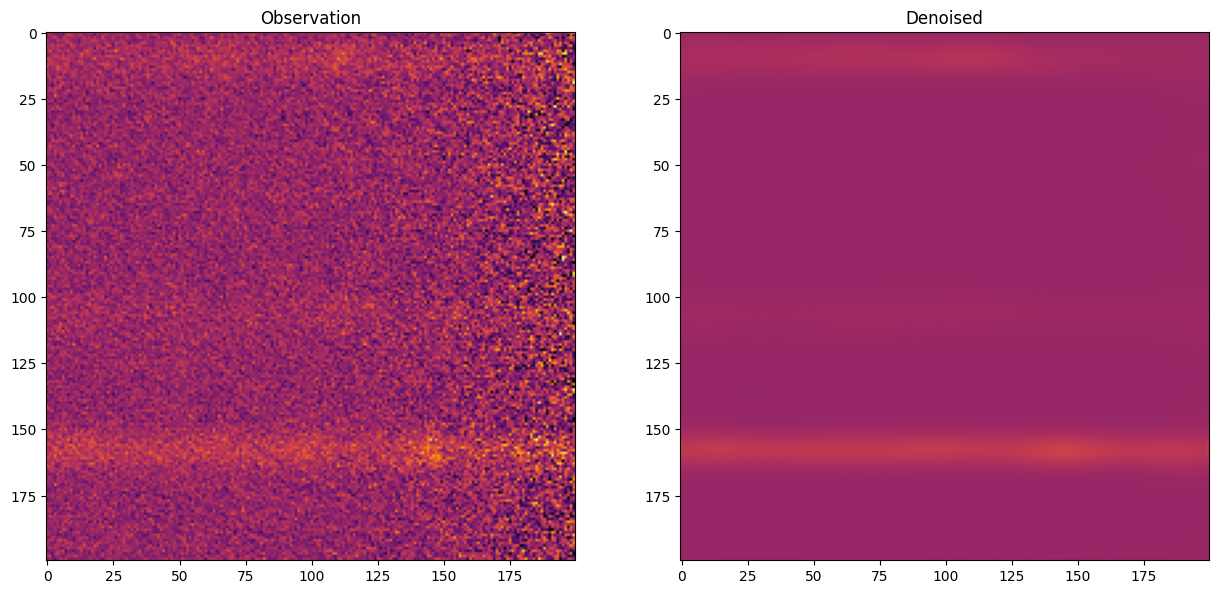

In [11]:
import sys
sys.path.append('../')
from utils.tools import plot

idx = np.random.randint(avg.shape[0])
sample_idx = np.random.randint(100)

vmin = np.percentile(observation, 0.1)
vmax = np.percentile(observation, 99.9)



plot(
    [observation[idx], avg[idx]],
    ["Observation", "Denoised", "Ground truth"],
    vmin=vmin,
    vmax=vmax,
    cmap="inferno",
    figsize=(15, 15),
)

/var/folders/ft/d5_ys37x417gbwg28lxf87600000gn/T/ipykernel_72289/1264767318.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("cividis")


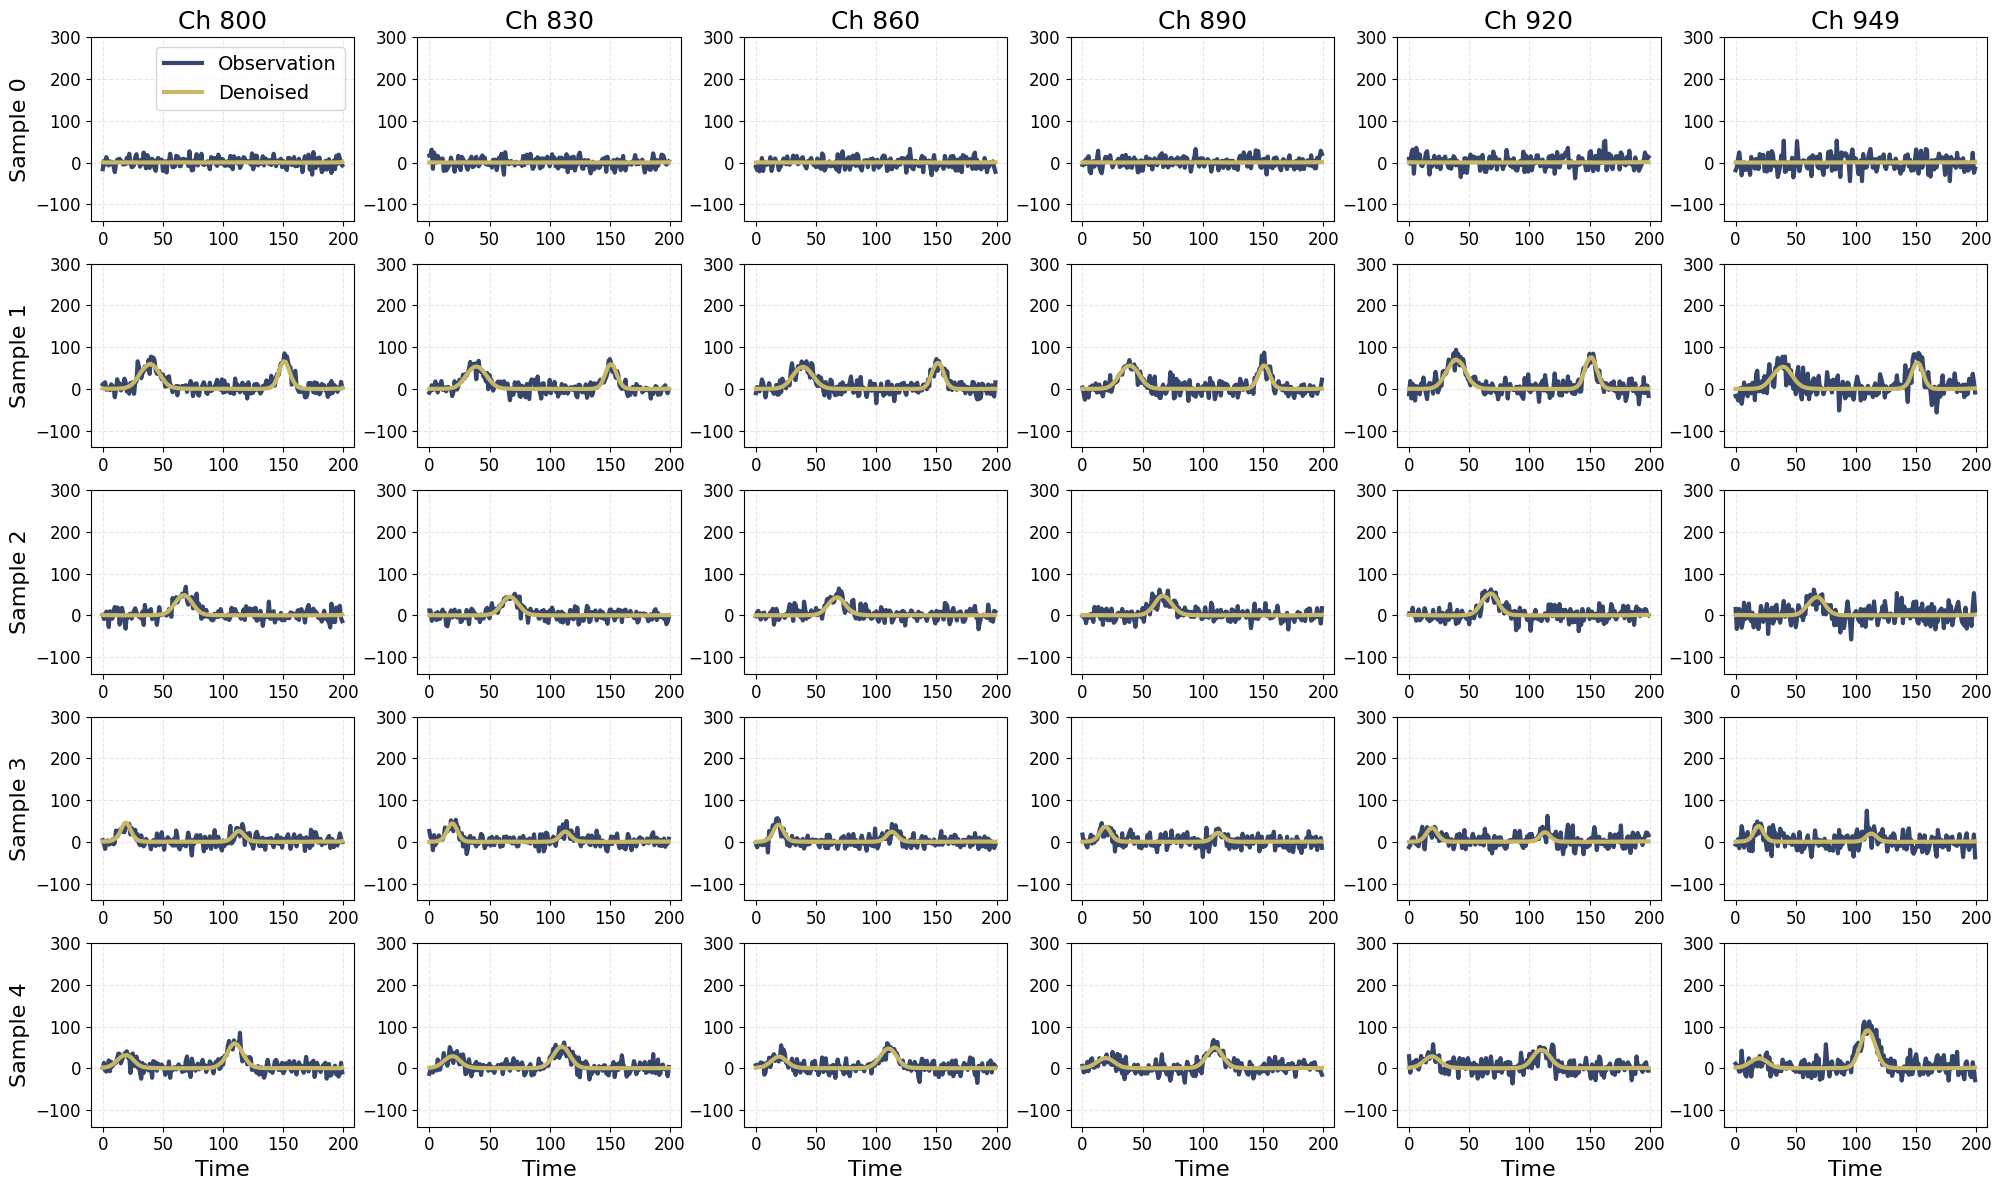

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# =========================
# 設定
# =========================
samples_to_plot = 5
channels = [0, 30, 60, 90, 120, 149]

cmap = cm.get_cmap("cividis")
color_obs = cmap(0.2)
color_avg = cmap(0.5)
color_gt = cmap(0.8)

fontsize_title = 18
fontsize_label = 16
fontsize_tick = 12
fontsize_legend = 14

# ===== 共通y軸 =====
y_min = min(observation.min(), avg.min())
# y_max = max(observation.max(), avg.max())
y_max = 300

fig, axes = plt.subplots(samples_to_plot, len(channels), figsize=(20, 12))

for i in range(samples_to_plot):
    for j, ch in enumerate(channels):
        ax = axes[i, j]

        ax.plot(observation[i, :, ch], color=color_obs, linewidth=3, label="Observation")
        ax.plot(avg[i, :, ch], color=color_gt, linewidth=3, label="Denoised")
        # ax.plot(gt[i, :, ch], color=color_gt, linewidth=3, label="Ground truth")

        # 共通y軸
        ax.set_ylim(y_min, y_max)

        # タイトル
        if i == 0:
            ax.set_title(f"Ch {ch+800}", fontsize=fontsize_title)

        # 行ラベル
        if j == 0:
            ax.set_ylabel(f"Sample {i}", fontsize=fontsize_label)

        # 横軸ラベル
        if i == samples_to_plot - 1:
            ax.set_xlabel("Time", fontsize=fontsize_label)

        ax.tick_params(axis='both', labelsize=fontsize_tick)
        ax.grid(True, alpha=0.3, linestyle="--")

        if i == 0 and j == 0:
            ax.legend(fontsize=fontsize_legend)

plt.tight_layout()
plt.show()

/var/folders/ft/d5_ys37x417gbwg28lxf87600000gn/T/ipykernel_72289/683901560.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("cividis")


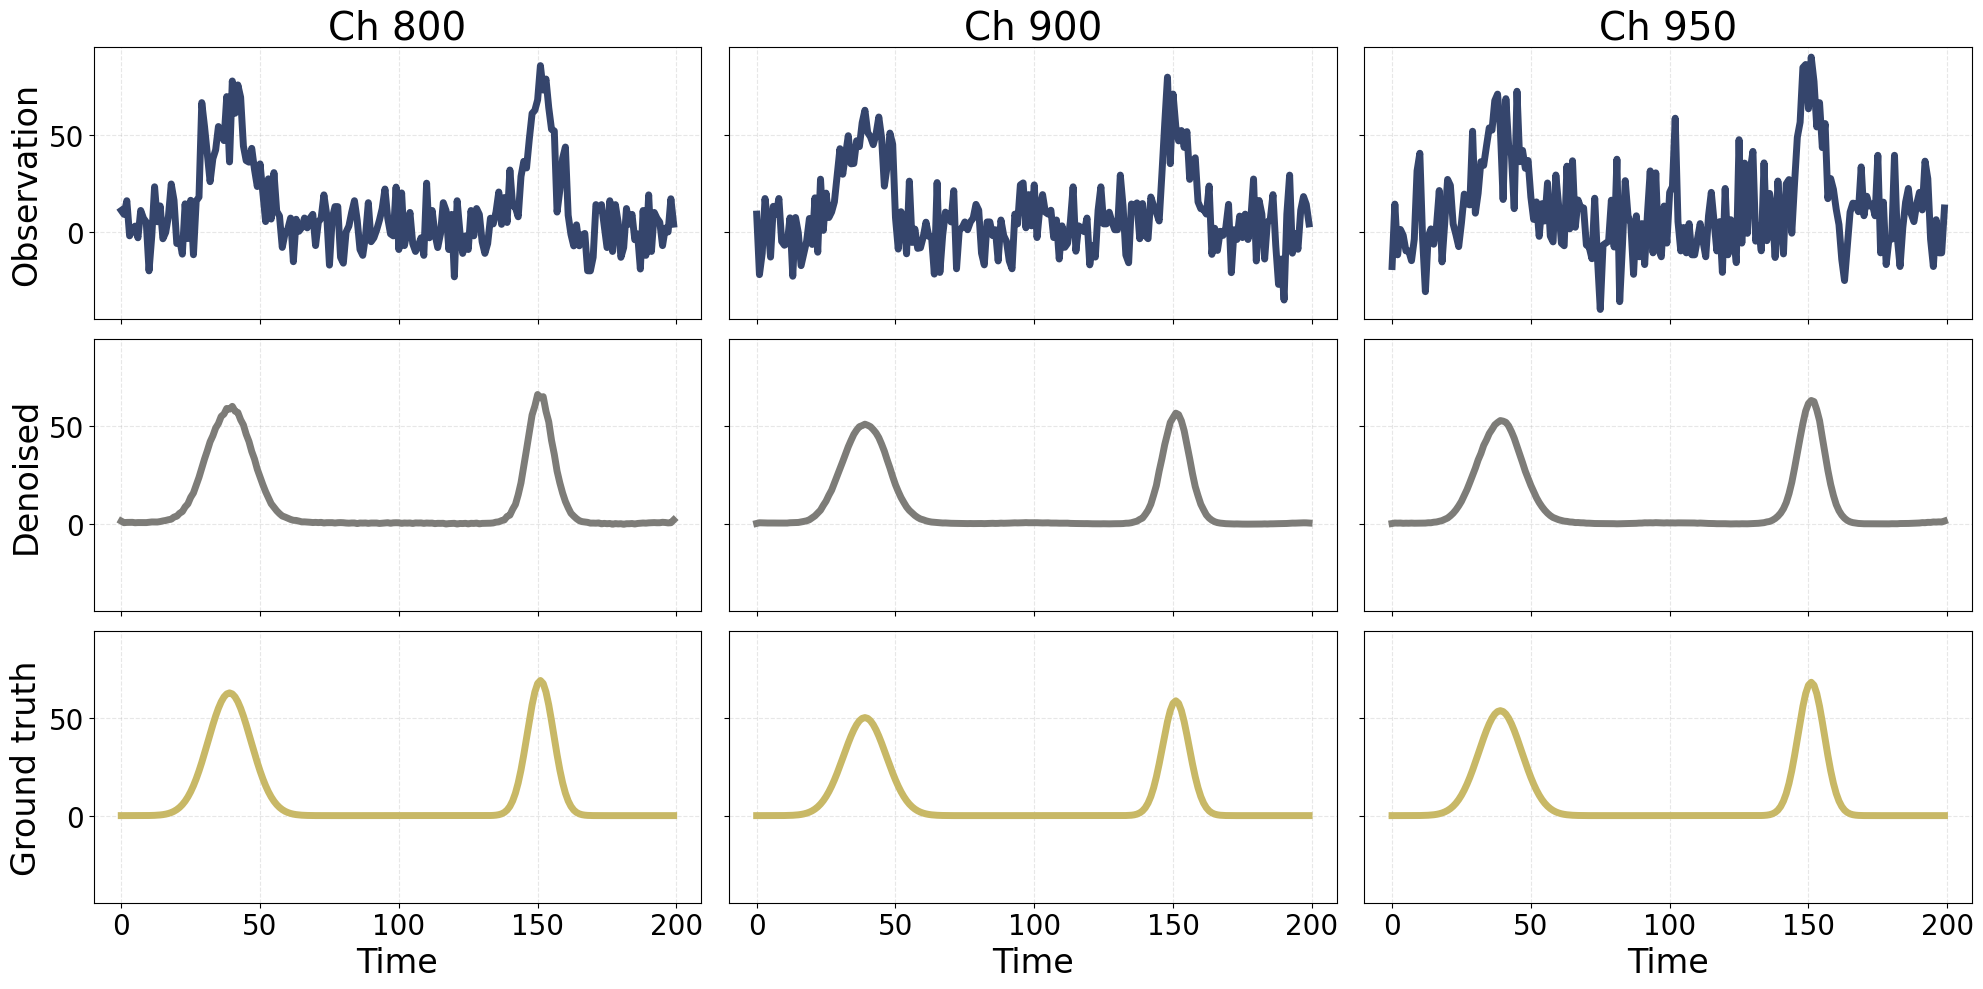

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== 設定 =====
sample_idx = 1

channels = [0, 100, 150]
offset = 800

cmap = cm.get_cmap("cividis")
color_obs = cmap(0.2)
color_avg = cmap(0.5)
color_gt = cmap(0.8)

fontsize_title = 28
fontsize_label = 24
fontsize_tick = 20

linewidth = 5

# ===== ここが重要（全体のy範囲を計算）=====
all_values = []

for ch in channels:
    all_values.append(observation[sample_idx, :, ch])
    all_values.append(avg[sample_idx, :, ch])
    all_values.append(gt[sample_idx, :, ch])

all_values = np.concatenate(all_values)

y_min = all_values.min()
y_max = all_values.max()

# ===== plot =====
fig, axes = plt.subplots(3, len(channels), figsize=(20, 10), sharex=True, sharey=True)

row_titles = ["Observation", "Denoised", "Ground truth"]

for j, ch in enumerate(channels):

    obs_signal = observation[sample_idx, :, ch]
    avg_signal = avg[sample_idx, :, ch]
    gt_signal  = gt[sample_idx, :, ch]

    time_axis = np.arange(len(obs_signal))

    axes[0, j].plot(time_axis, obs_signal, color=color_obs, linewidth=linewidth)
    axes[1, j].plot(time_axis, avg_signal, color=color_avg, linewidth=linewidth)
    axes[2, j].plot(time_axis, gt_signal, color=color_gt, linewidth=linewidth)

    axes[0, j].set_title(f"Ch {ch + offset}", fontsize=fontsize_title)

    for i in range(3):
        ax = axes[i, j]

        # ===== ここで統一 =====
        ax.set_ylim(y_min-5, y_max+5)

        ax.grid(True, alpha=0.3, linestyle="--")
        ax.tick_params(axis='both', labelsize=fontsize_tick)

        if j == 0:
            ax.set_ylabel(row_titles[i], fontsize=fontsize_label)

        if i == 2:
            ax.set_xlabel("Time", fontsize=fontsize_label)

plt.tight_layout()
plt.show()

/var/folders/ft/d5_ys37x417gbwg28lxf87600000gn/T/ipykernel_72289/469721902.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("cividis")


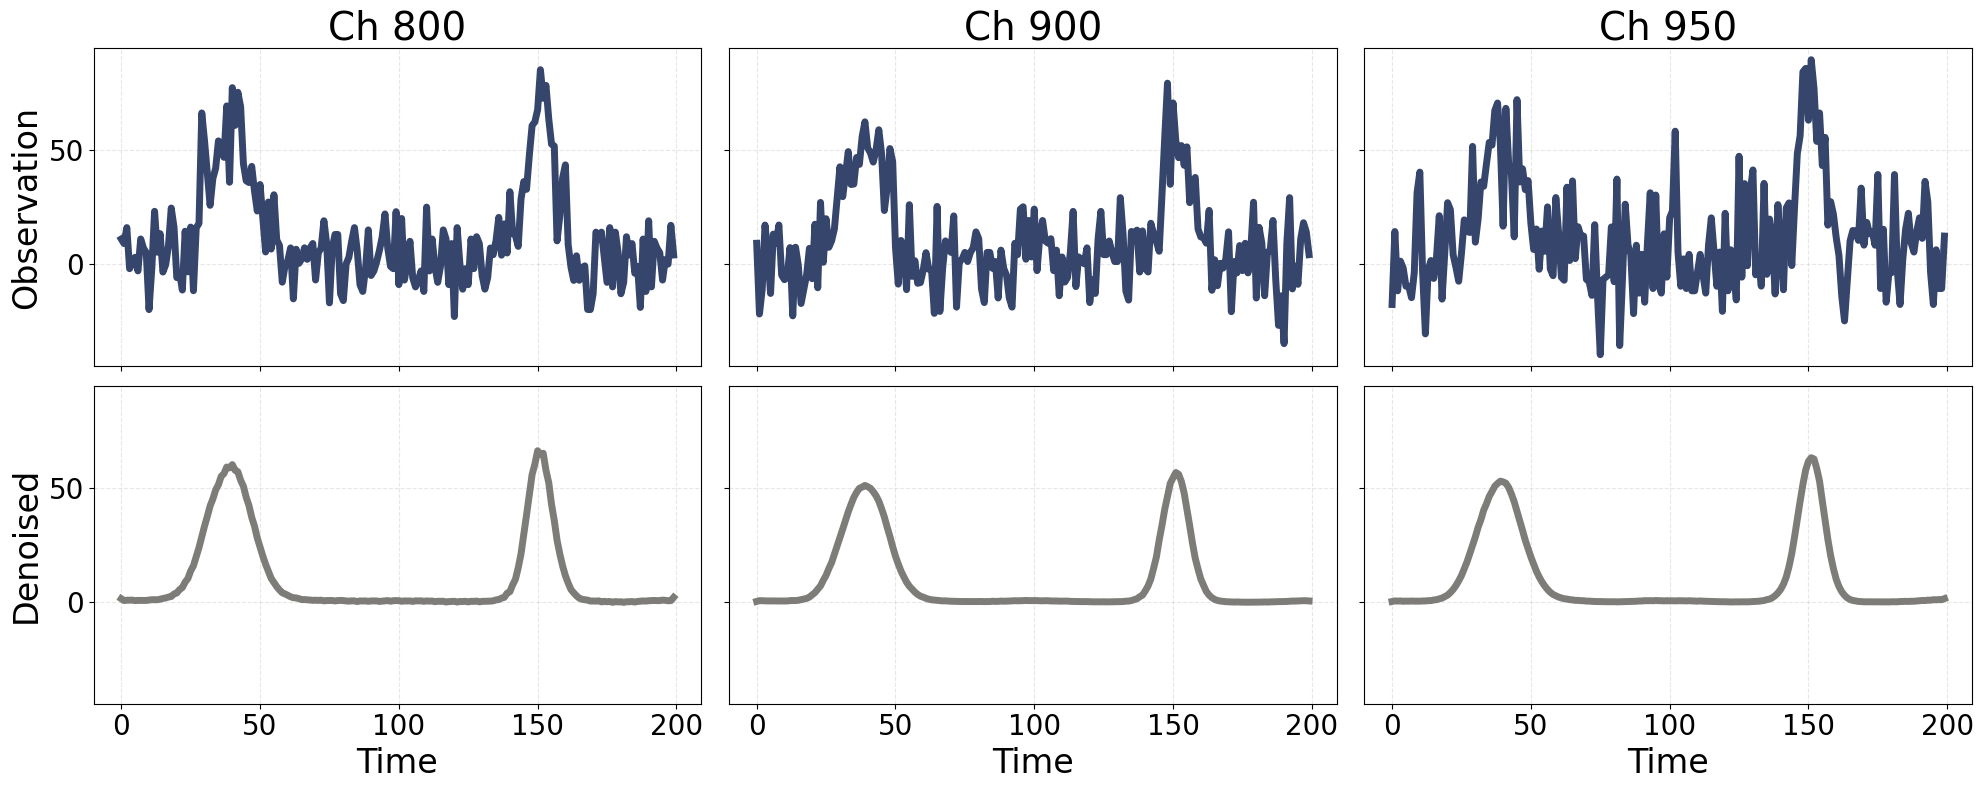

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== 設定 =====
sample_idx = 1

channels = [0, 100, 150]  # 修正（150→149）
offset = 800

cmap = cm.get_cmap("cividis")
color_obs = cmap(0.2)
color_avg = cmap(0.5)

fontsize_title = 28
fontsize_label = 24
fontsize_tick = 20

linewidth = 5

# ===== y軸範囲（obs + avgだけ）=====
all_values = []

for ch in channels:
    all_values.append(observation[sample_idx, :, ch])
    all_values.append(avg[sample_idx, :, ch])

all_values = np.concatenate(all_values)

y_min = all_values.min()
y_max = all_values.max()

# ===== plot（2行）=====
fig, axes = plt.subplots(2, len(channels), figsize=(20, 8), sharex=True, sharey=True)

row_titles = ["Observation", "Denoised"]

for j, ch in enumerate(channels):

    obs_signal = observation[sample_idx, :, ch]
    avg_signal = avg[sample_idx, :, ch]

    time_axis = np.arange(len(obs_signal))

    # ===== プロット =====
    axes[0, j].plot(time_axis, obs_signal, color=color_obs, linewidth=linewidth)
    axes[1, j].plot(time_axis, avg_signal, color=color_avg, linewidth=linewidth)

    axes[0, j].set_title(f"Ch {ch + offset}", fontsize=fontsize_title)

    for i in range(2):
        ax = axes[i, j]

        # y軸統一
        ax.set_ylim(y_min - 5, y_max + 5)

        ax.grid(True, alpha=0.3, linestyle="--")
        ax.tick_params(axis='both', labelsize=fontsize_tick)

        # 行ラベル
        if j == 0:
            ax.set_ylabel(row_titles[i], fontsize=fontsize_label)

        # xラベル（最下段）
        if i == 1:
            ax.set_xlabel("Time", fontsize=fontsize_label)

plt.tight_layout()
plt.show()

/var/folders/ft/d5_ys37x417gbwg28lxf87600000gn/T/ipykernel_72289/1870841888.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("cividis")


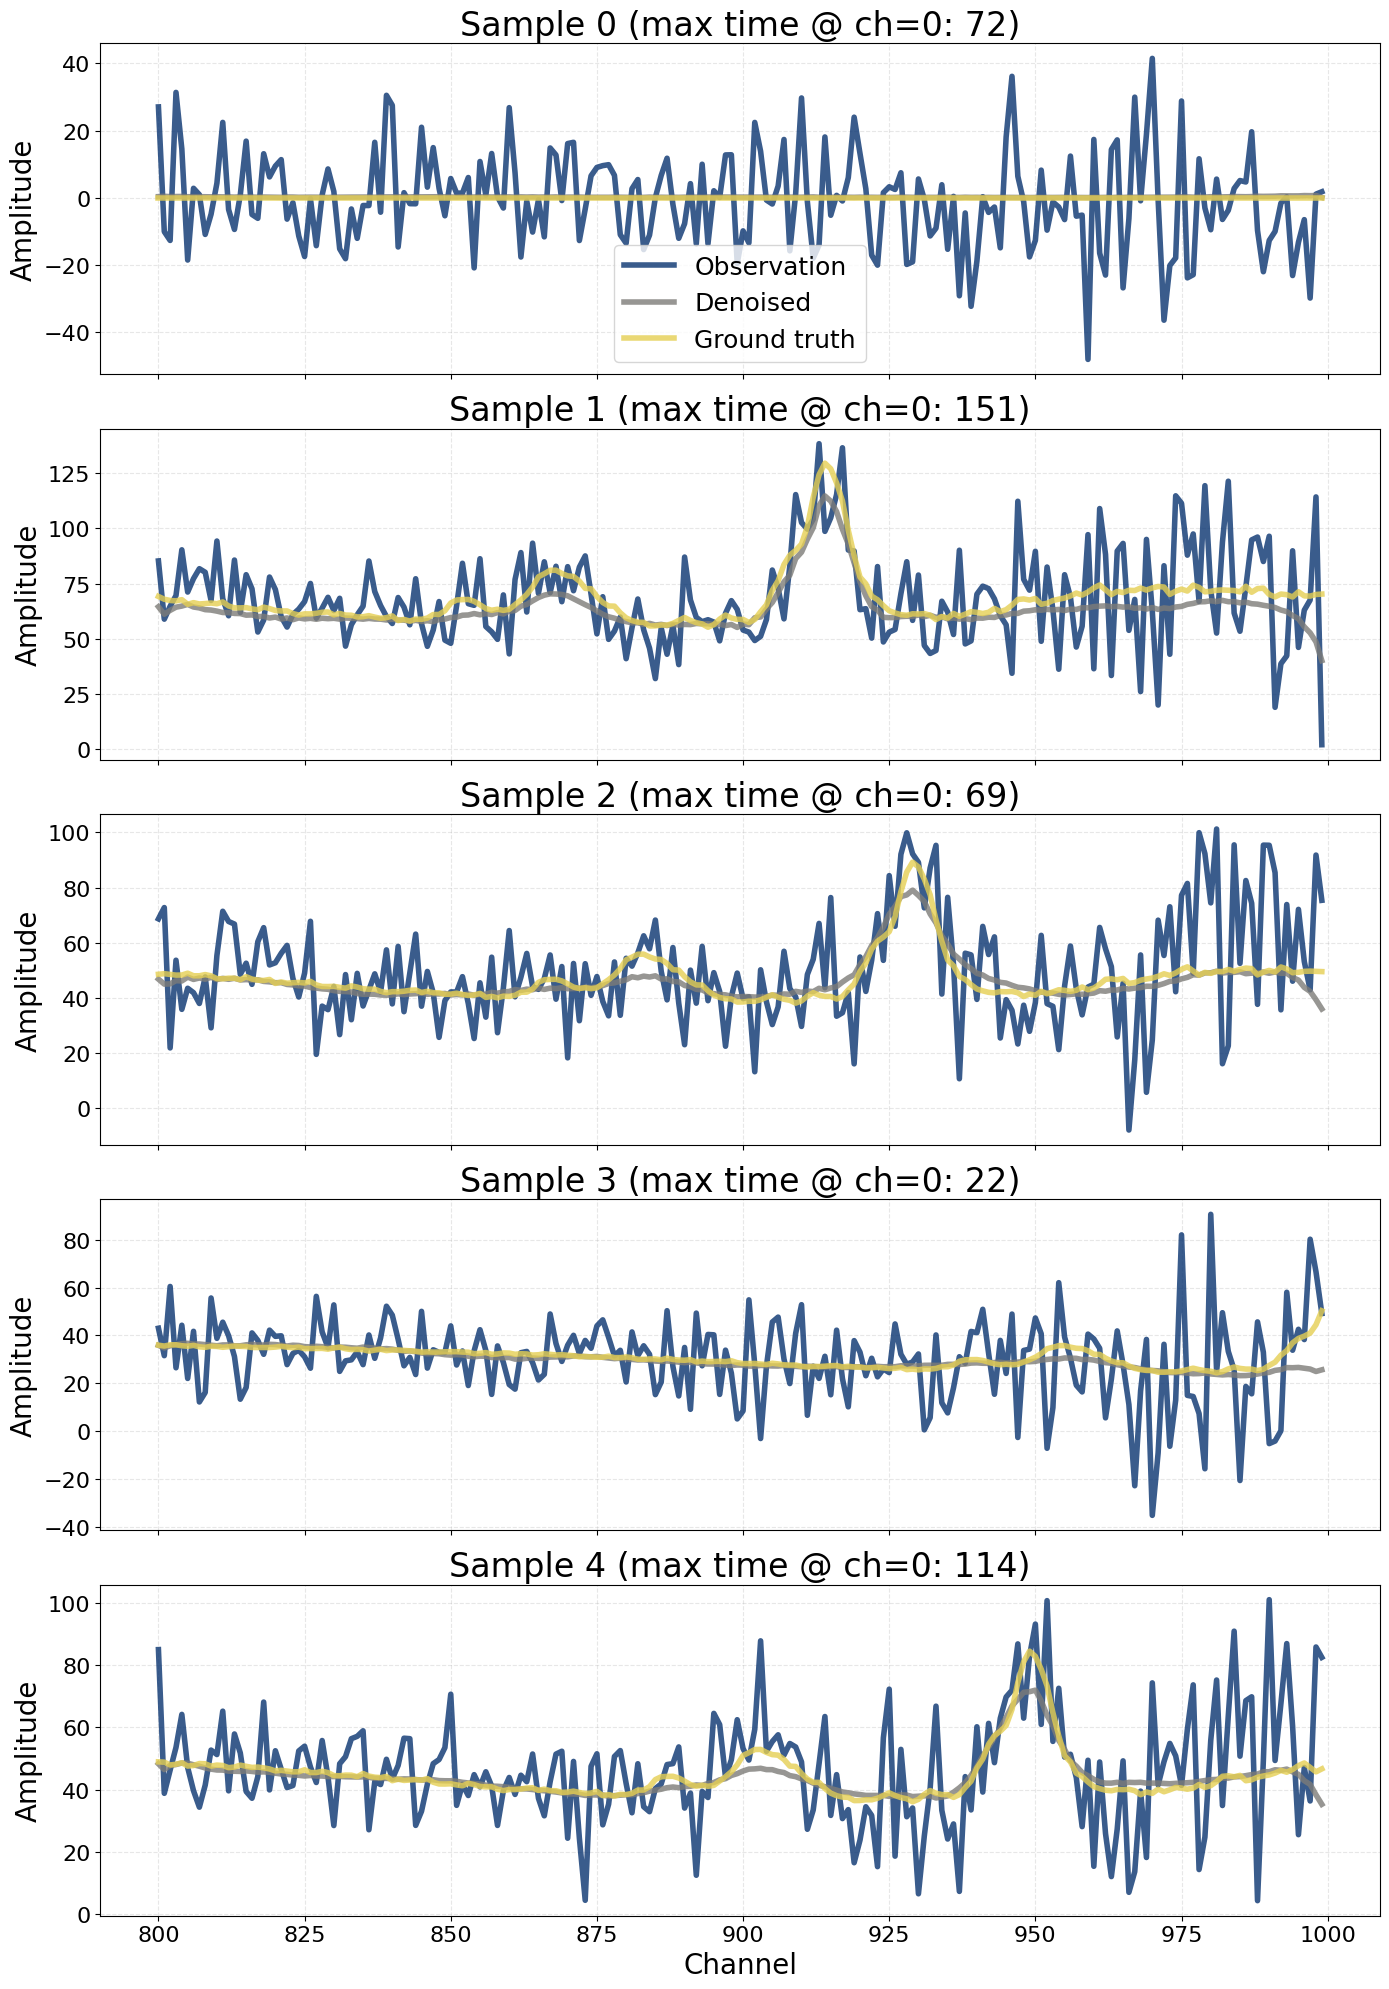

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== settings =====
samples_to_plot = 5

cmap = cm.get_cmap("cividis")
color_obs = cmap(0.1)
color_avg = cmap(0.5)
color_gt = cmap(0.9)

# フォント大きめ
fontsize_title = 24
fontsize_label = 20
fontsize_tick = 16
fontsize_legend = 18

# 線をさらに太く
linewidth = 4
# 透明度（薄く）
alpha = 0.8

offset = 800

# ===== plot =====
fig, axes = plt.subplots(samples_to_plot, 1, figsize=(14, 20), sharex=True)

if samples_to_plot == 1:
    axes = [axes]

for i in range(samples_to_plot):
    ax = axes[i]

    # channel=0 の最大時間
    t_max = np.argmax(observation[i, :, 0])

    # チャネル方向プロファイル
    obs_profile = observation[i, t_max, :]
    avg_profile = avg[i, t_max, :]
    gt_profile = gt[i, t_max, :]

    ch_axis = np.arange(observation.shape[2]) + offset

    ax.plot(ch_axis, obs_profile, linewidth=linewidth, color=color_obs, alpha=alpha,label="Observation")
    ax.plot(ch_axis, avg_profile, linewidth=linewidth, color=color_avg, alpha=alpha, label="Denoised")
    ax.plot(ch_axis, gt_profile, linewidth=linewidth, color=color_gt, alpha=alpha, label="Ground truth")

    ax.set_title(
        f"Sample {i} (max time @ ch=0: {t_max})",
        fontsize=fontsize_title
    )
    ax.set_ylabel("Amplitude", fontsize=fontsize_label)
    ax.tick_params(axis="both", labelsize=fontsize_tick)
    ax.grid(True, alpha=0.3, linestyle="--")

    if i == 0:
        ax.legend(fontsize=fontsize_legend)

axes[-1].set_xlabel("Channel", fontsize=fontsize_label)

plt.tight_layout()
plt.show()

/var/folders/ft/d5_ys37x417gbwg28lxf87600000gn/T/ipykernel_72289/2476555364.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("cividis")


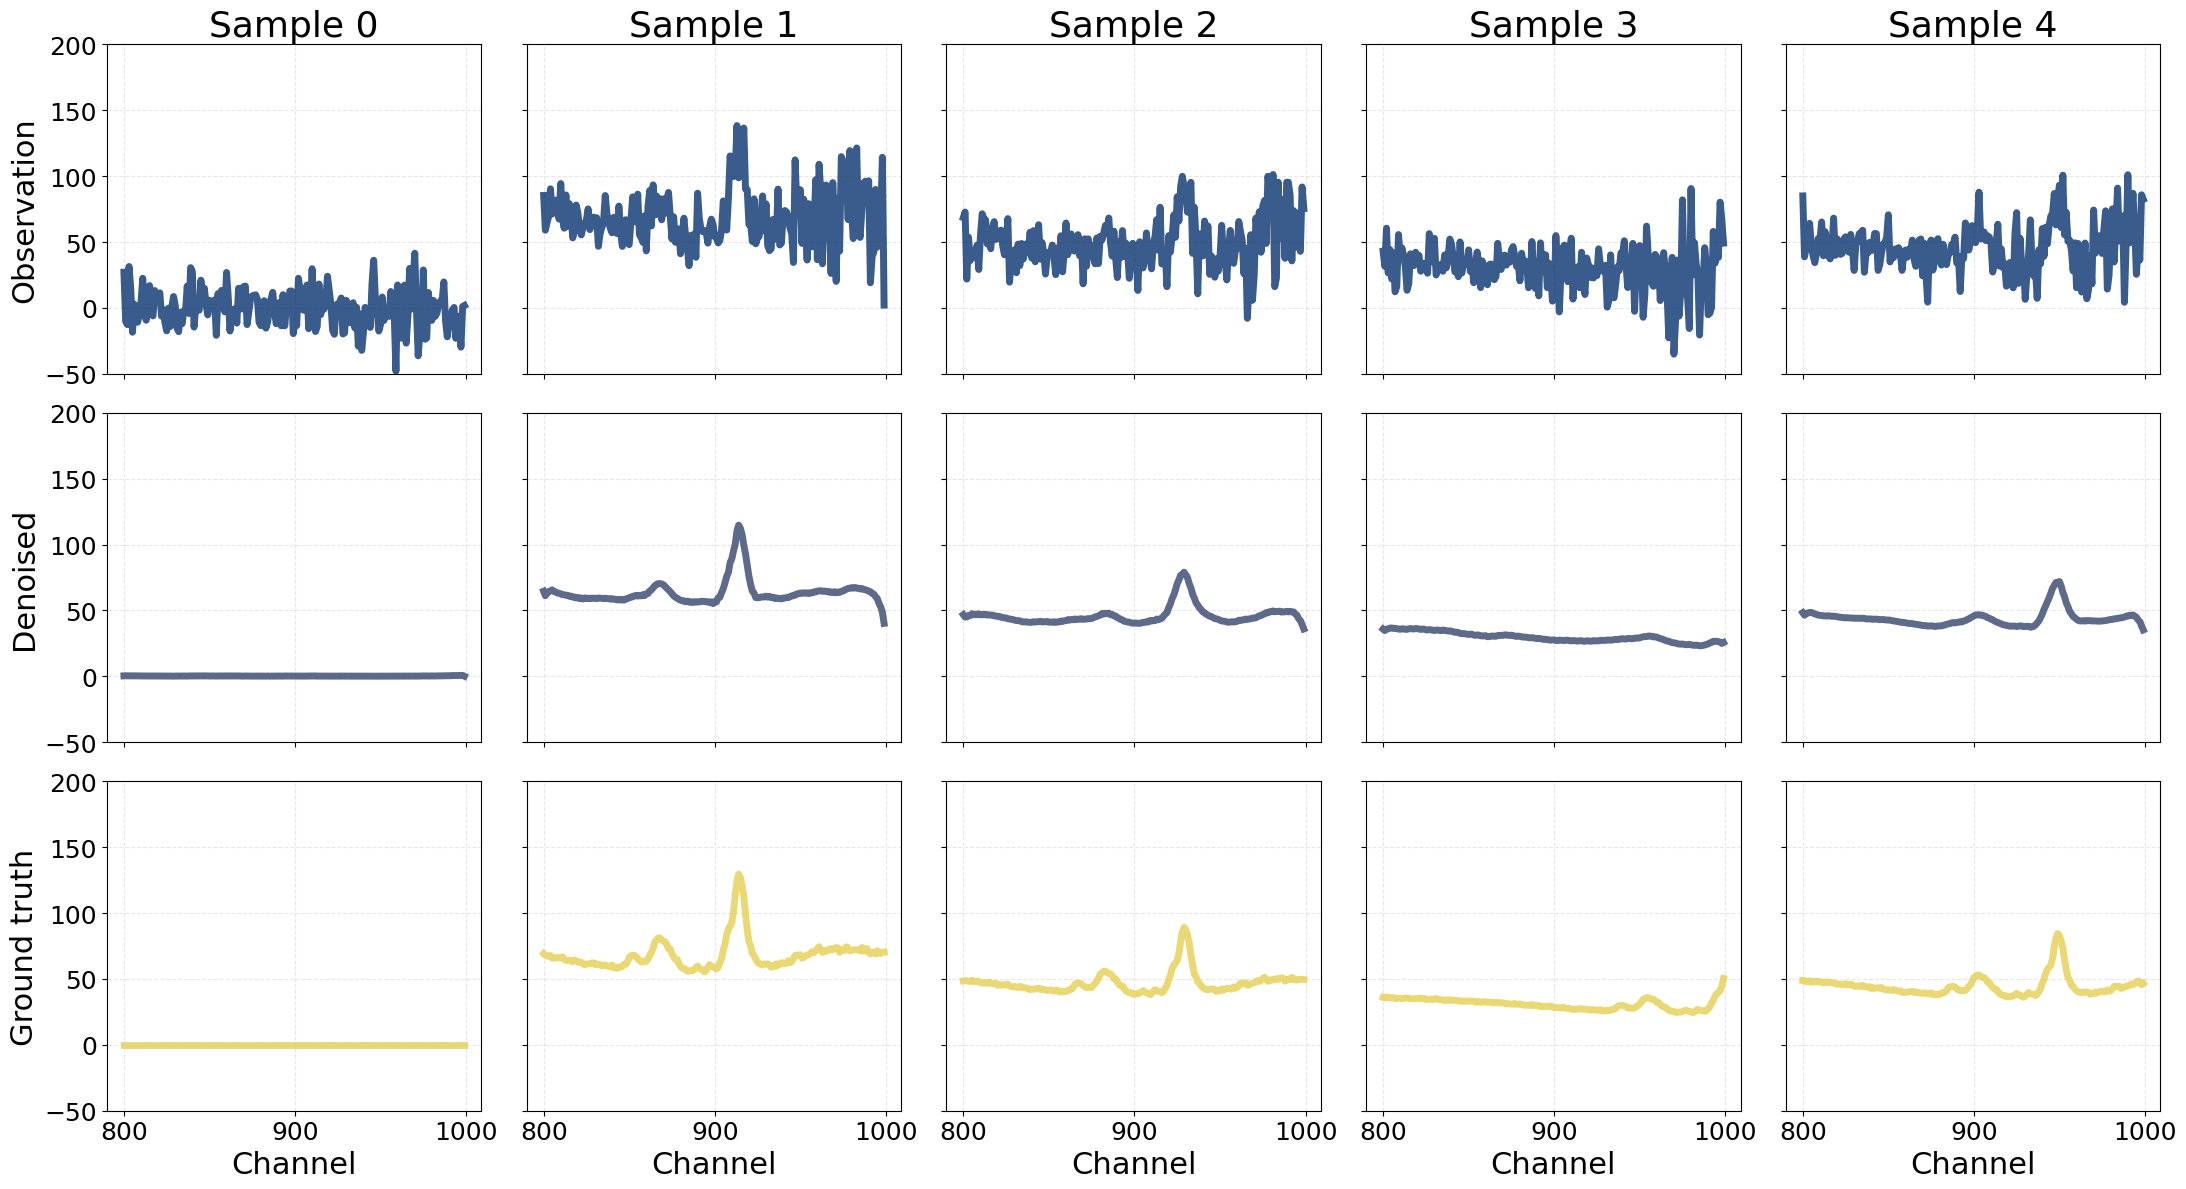

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== settings =====
samples_to_plot = 5

cmap = cm.get_cmap("cividis")
color_obs = cmap(0.1)
color_avg = cmap(0.2)
color_gt = cmap(0.9)

# ===== フォントをさらに大きく =====
fontsize_title = 26
fontsize_label = 22
fontsize_tick = 18

linewidth = 5
alpha = 0.8
offset = 800

# ===== plot =====
fig, axes = plt.subplots(3, samples_to_plot, figsize=(22, 12), sharex=True, sharey=True)

row_titles = ["Observation", "Denoised", "Ground truth"]

for i in range(samples_to_plot):

    t_max = np.argmax(observation[i, :, 0])

    obs_profile = observation[i, t_max, :]
    avg_profile = avg[i, t_max, :]
    gt_profile = gt[i, t_max, :]

    ch_axis = np.arange(observation.shape[2]) + offset

    # 各行プロット
    axes[0, i].plot(ch_axis, obs_profile, linewidth=linewidth, color=color_obs, alpha=alpha)
    axes[1, i].plot(ch_axis, avg_profile, linewidth=linewidth, color=color_avg, alpha=alpha)
    axes[2, i].plot(ch_axis, gt_profile, linewidth=linewidth, color=color_gt, alpha=alpha)

    for r in range(3):
        ax = axes[r, i]

        ax.set_ylim(-50, 200)

        ax.grid(True, alpha=0.3, linestyle="--")
        ax.tick_params(axis="both", labelsize=fontsize_tick)

        if i == 0:
            ax.set_ylabel(row_titles[r], fontsize=fontsize_label)

        if r == 2:
            ax.set_xlabel("Channel", fontsize=fontsize_label)

    axes[0, i].set_title(f"Sample {i}", fontsize=fontsize_title)

plt.tight_layout()
plt.show()

/var/folders/ft/d5_ys37x417gbwg28lxf87600000gn/T/ipykernel_72289/2381469855.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("cividis")


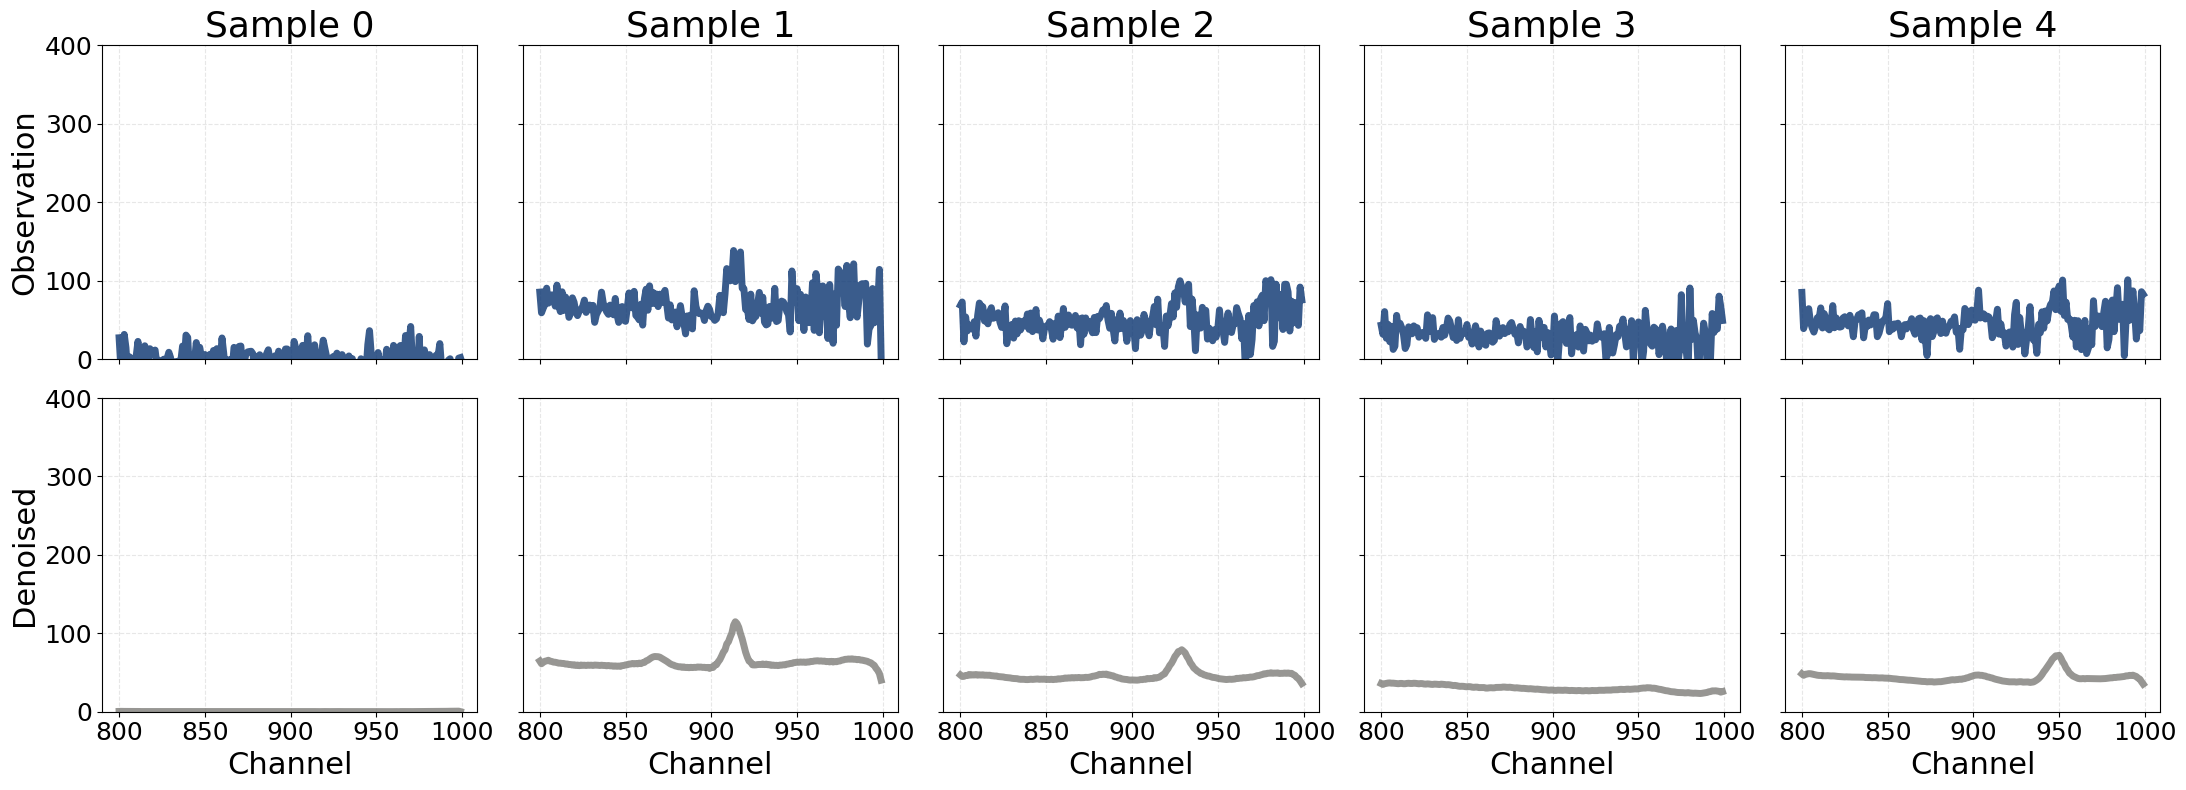

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== settings =====
samples_to_plot = 5

cmap = cm.get_cmap("cividis")
color_obs = cmap(0.1)
color_avg = cmap(0.5)

# ===== フォント =====
fontsize_title = 26
fontsize_label = 22
fontsize_tick = 18

linewidth = 5
alpha = 0.8
offset = 800

# ===== plot（2行に変更）=====
fig, axes = plt.subplots(2, samples_to_plot, figsize=(22, 8), sharex=True, sharey=True)

row_titles = ["Observation", "Denoised"]

for i in range(samples_to_plot):

    t_max = np.argmax(observation[i, :, 0])

    obs_profile = observation[i, t_max, :]
    avg_profile = avg[i, t_max, :]

    ch_axis = np.arange(observation.shape[2]) + offset

    # ===== プロット =====
    axes[0, i].plot(ch_axis, obs_profile, linewidth=linewidth, color=color_obs, alpha=alpha)
    axes[1, i].plot(ch_axis, avg_profile, linewidth=linewidth, color=color_avg, alpha=alpha)

    for r in range(2):
        ax = axes[r, i]

        ax.set_ylim(0, 400)

        ax.grid(True, alpha=0.3, linestyle="--")
        ax.tick_params(axis="both", labelsize=fontsize_tick)

        # 行ラベル（左端だけ）
        if i == 0:
            ax.set_ylabel(row_titles[r], fontsize=fontsize_label)

        # xラベル（最下段だけ）
        if r == 1:
            ax.set_xlabel("Channel", fontsize=fontsize_label)

    axes[0, i].set_title(f"Sample {i}", fontsize=fontsize_title)

plt.tight_layout()
plt.show()